**Задание для семинара**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import missingno
print("ok")

ok


## Задание 1. Загрузка и осмотр данных

In [3]:
df=sns.load_dataset('mpg')
print(type(df))
df.head()


<class 'pandas.DataFrame'>


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

In [5]:
df.shape

(398, 9)

In [6]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [7]:
print("Количество уникальных значений:", df['origin'].nunique())
print("Уникальные значения:", df['origin'].unique())

Количество уникальных значений: 3
Уникальные значения: <StringArray>
['usa', 'japan', 'europe']
Length: 3, dtype: str


In [8]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [9]:
df['horsepower'].head()


0    130.0
1    165.0
2    150.0
3    150.0
4    140.0
Name: horsepower, dtype: float64

## Задание 2. Обработка пропущенных значений

<Axes: >

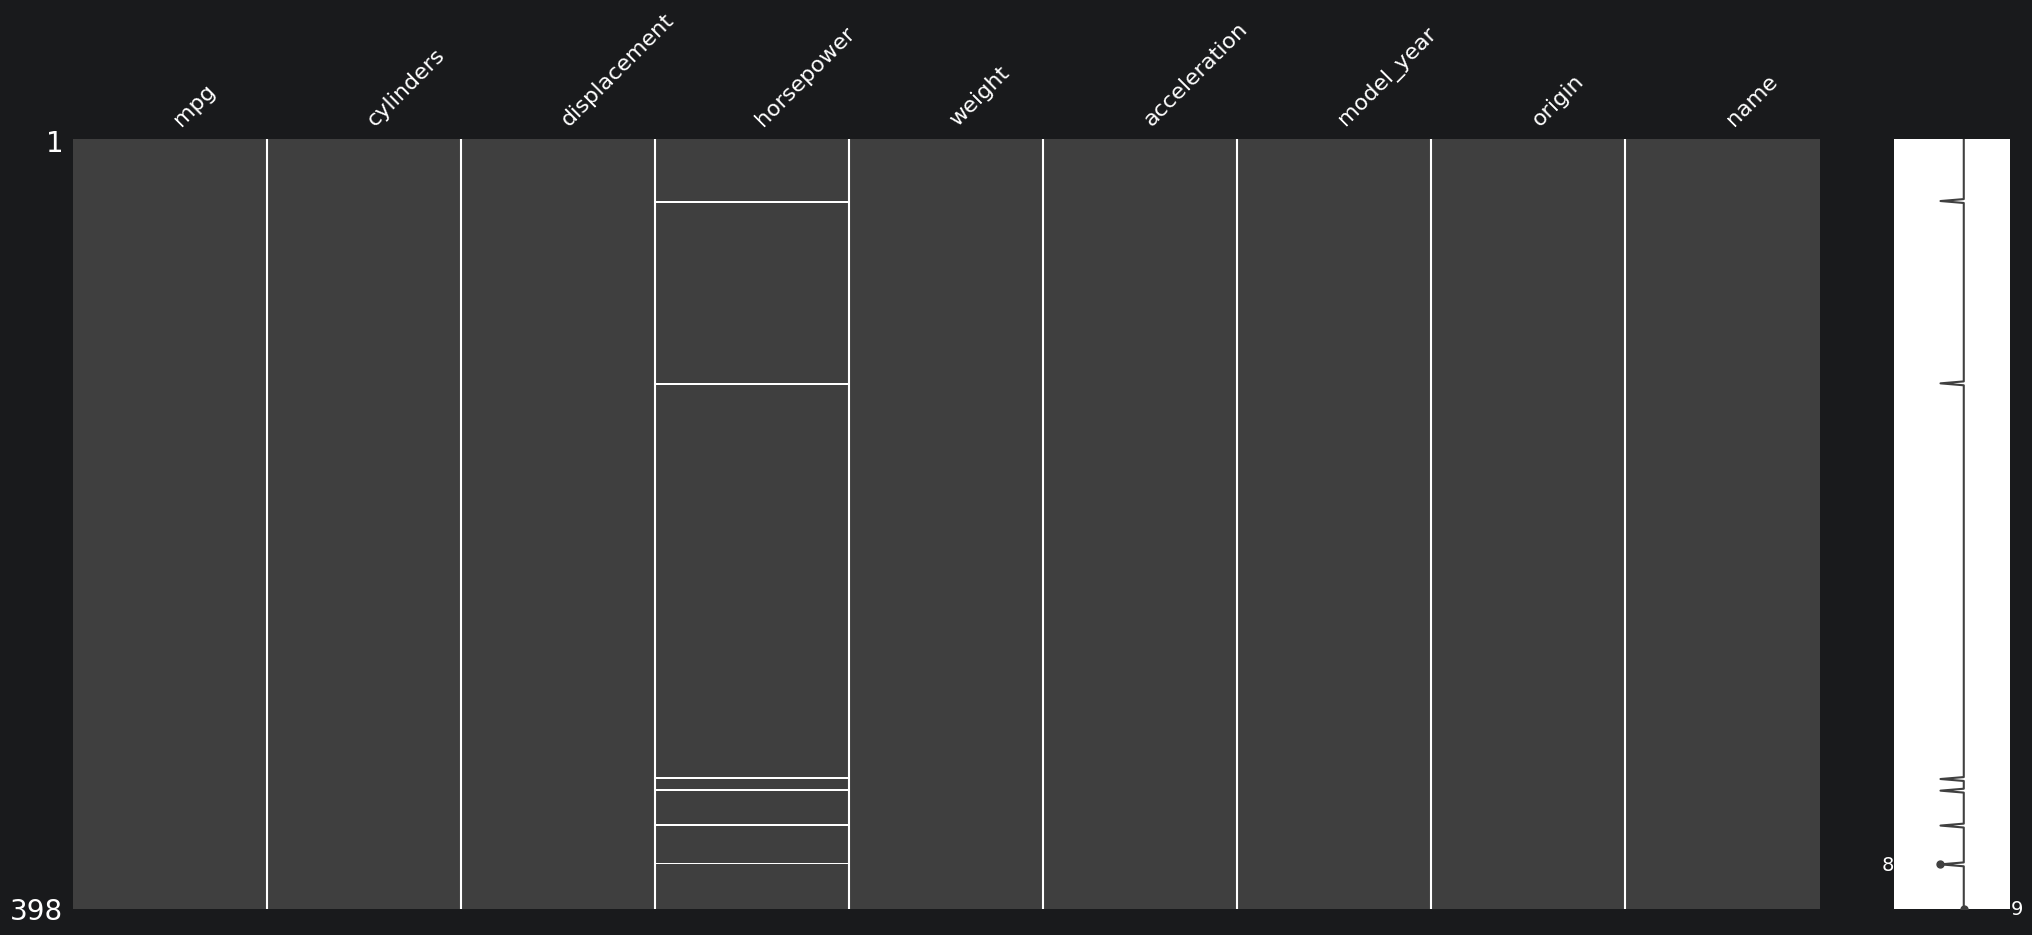

In [10]:
import missingno as msno
msno.matrix(df)

In [11]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df['horsepower']=imputer.fit_transform(df[['horsepower']])

<Axes: >

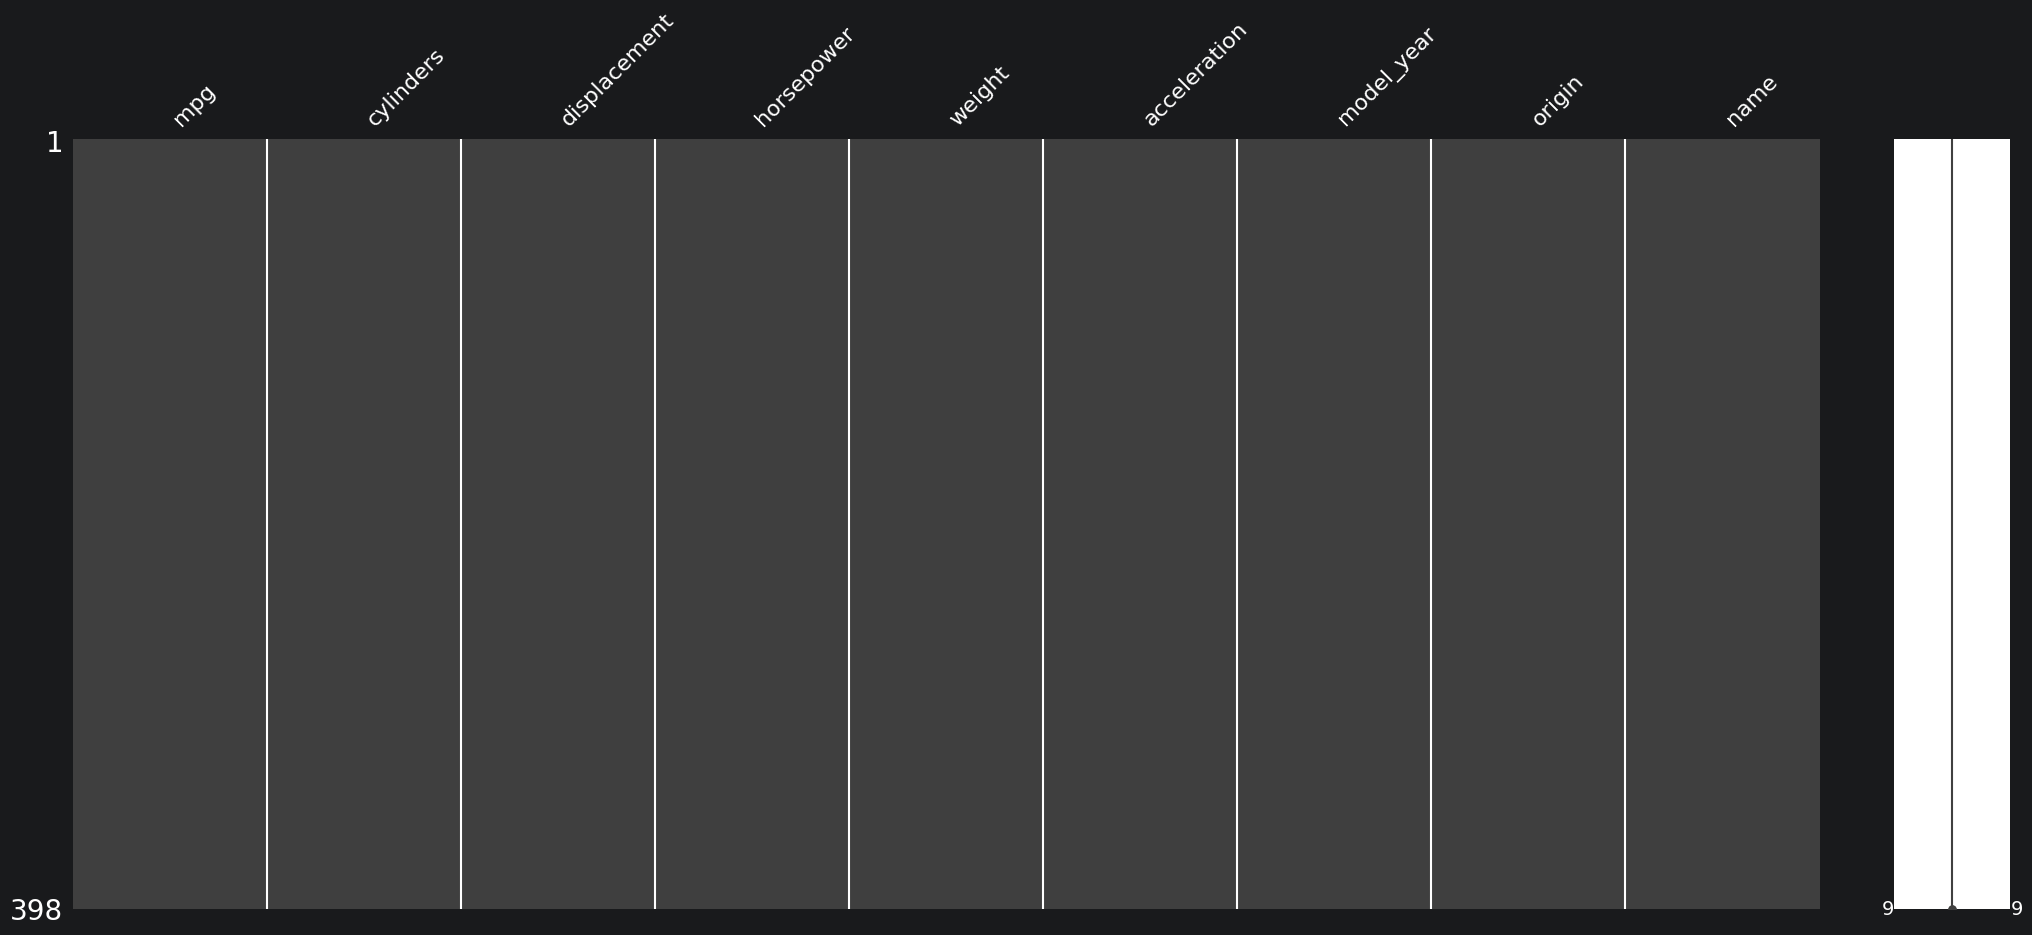

In [12]:
msno.matrix(df)

## Задание 3. Обработка дубликатов
Дубликатов нет

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df=df.drop_duplicates()

In [15]:
df.shape

(398, 9)

## Задание 4. Обнаружение и обработка выбросов

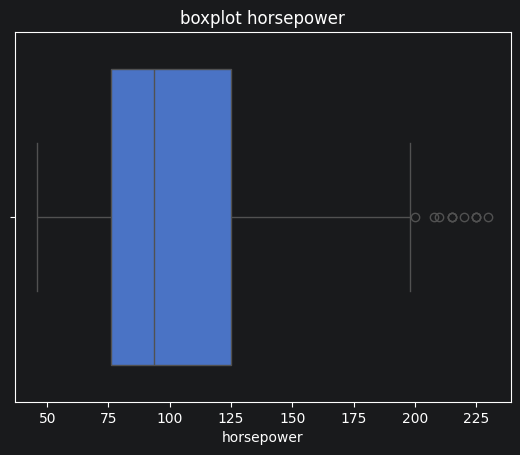

In [16]:
import seaborn as sns
sns.boxplot(x=df['horsepower'])
plt.title("boxplot horsepower")
plt.show()

In [17]:
Q1 = df['horsepower'].quantile(0.25)
Q3 = df['horsepower'].quantile(0.75)
print(f"Q1:{Q1} Q3:{Q3}")
IQR = Q3 - Q1
print(f"IQR:{IQR}")
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Нижняя граница:", lower_bound)
print("Верхняя граница:", upper_bound)
outliers = df[(df['horsepower'] < lower_bound) | (df['horsepower'] > upper_bound)]
print("Количество выбросов:", outliers.shape[0])

Q1:76.0 Q3:125.0
IQR:49.0
Нижняя граница: 2.5
Верхняя граница: 198.5
Количество выбросов: 11


**Z-Score**

In [18]:
from scipy import stats
z_score=np.abs(stats.zscore(df['horsepower']))
outliers=df[z_score>3]
print("Количество выбросов:", outliers.shape[0])

Количество выбросов: 5


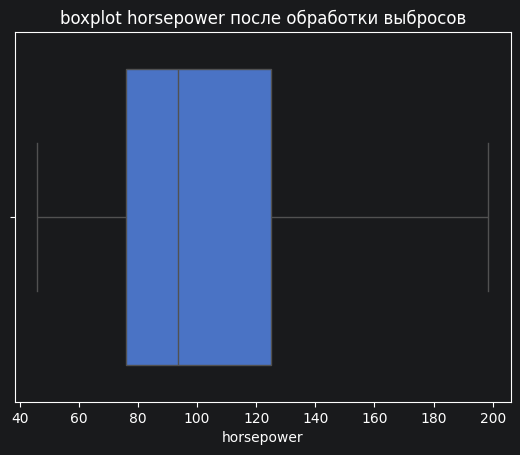

In [19]:
df['horsepower'] = df['horsepower'].clip(lower=lower_bound, upper=upper_bound)
sns.boxplot(x=df['horsepower'])
plt.title("boxplot horsepower после обработки выбросов")
plt.show()

## Задание 5. Стандартизация числовых переменных

In [20]:
from sklearn.preprocessing import StandardScaler
numeric_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])
mpg_scaled=pd.DataFrame(scaled_data, columns=numeric_cols)
print(f"Среднее значение после стандартизации: {mpg_scaled.mean()}")
print(f"Стандартное отклонение после стандартизации: {mpg_scaled.std()}")
scaled_data

Среднее значение после стандартизации: mpg             7.141133e-17
displacement   -1.785283e-17
horsepower      0.000000e+00
weight         -1.606755e-16
acceleration   -2.677925e-16
dtype: float64
Стандартное отклонение после стандартизации: mpg             1.001259
displacement    1.001259
horsepower      1.001259
weight          1.001259
acceleration    1.001259
dtype: float64


array([[-0.7064387 ,  1.0906037 ,  0.71369197,  0.63086987, -1.29549834],
       [-1.09075062,  1.5035143 ,  1.66674084,  0.85433297, -1.47703779],
       [-0.7064387 ,  1.19623199,  1.25829132,  0.55047045, -1.65857724],
       ...,
       [ 1.08701694, -0.56103873, -0.53888653, -0.79858454, -1.4407299 ],
       [ 0.57460104, -0.70507731, -0.67503637, -0.40841088,  1.10082237],
       [ 0.95891297, -0.71467988, -0.59334646, -0.29608816,  1.39128549]],
      shape=(398, 5))

In [21]:
mpg_scaled.head()

,mpg,displacement,horsepower,weight,acceleration
0,-0.706439,1.090604,0.713692,0.630870,-1.295498
1,-1.090751,1.503514,1.666741,0.854333,-1.477038
2,-0.706439,1.196232,1.258291,0.550470,-1.658577
3,-0.962647,1.061796,1.258291,0.546923,-1.295498
4,-0.834543,1.042591,0.985992,0.565841,-1.840117


## Задание 6. Кодирование категориальных переменных


In [22]:
print(df['origin'].value_counts())
print("Количество категорий: ", df['origin'].nunique())

origin
usa       249
japan      79
europe     70
Name: count, dtype: int64
Количество категорий:  3


In [23]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop='first',sparse_output=False)
origin_encoded = encoder.fit_transform(df[['origin']])
encoded_columns=encoder.get_feature_names_out(['origin'])
origin_encoded_df=pd.DataFrame(origin_encoded, columns=encoded_columns)
mpg_scaled=pd.concat([mpg_scaled,origin_encoded_df],axis=1)
mpg_scaled.head()

,mpg,displacement,horsepower,weight,acceleration,origin_japan,origin_usa
0,-0.706439,1.090604,0.713692,0.630870,-1.295498,0.0,1.0
1,-1.090751,1.503514,1.666741,0.854333,-1.477038,0.0,1.0
2,-0.706439,1.196232,1.258291,0.550470,-1.658577,0.0,1.0
3,-0.962647,1.061796,1.258291,0.546923,-1.295498,0.0,1.0
4,-0.834543,1.042591,0.985992,0.565841,-1.840117,0.0,1.0


In [24]:
origin_dummies = pd.get_dummies(df['origin'], drop_first=True)

origin_dummies.head()

,japan,usa
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True


Результат отличается типом данных, при исполньзовании енкодера - float, при использовании get_dummies - bool

## Задание 7. Сохранение

In [25]:
mpg_scaled.to_csv('mpg_scaled.csv', index=False)
check_df=pd.read_csv('mpg_scaled.csv')
print(f"Shape: {check_df.shape}")

Shape: (398, 7)
